In [1]:
from pythtb import TBModel, Lattice, WFArray, Mesh
import numpy as np
import matplotlib.pyplot as plt

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 2
k-space dimension           = 2
periodic directions         = [0, 1]
spinful                     = False
number of spin components   = 1
number of electronic states = 2
number of orbitals          = 2

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000,  0.000]
  # 1 ===> [ 0.500,  0.866]
Volume of unit cell (Cartesian) = 0.866 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283, -3.628]
  # 1 ===> [ 0.000,  7.255]
Volume of reciprocal unit cell = 45.586 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 1.000,  0.577]

Orbital vectors (fractional):
  # 0 ===> [ 0.333,  0.333]
  # 1 ===> [ 0.667,  0.667]
----------------------------------------
Site energies:
  < 0 | H | 0 > =  0.000 
  < 1 | H | 1 > =  0.000 
Hoppings:
  < 0 | H | 1  + [ 0.0 ,  0.0 ] > = -1.0000+0.0000j
  < 1 | H | 0  + [ 1.0 , 

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

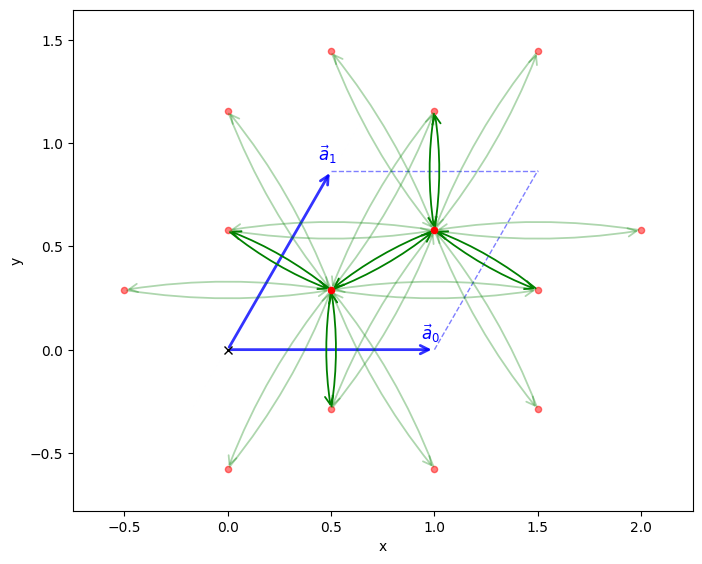

In [2]:
# define lattice vectors
lat_vecs = [[1, 0], [1 / 2, np.sqrt(3) / 2]]
# define coordinates of orbitals
orb_vecs = [[1 / 3, 1 / 3], [2 / 3, 2 / 3]]
lat = Lattice(lat_vecs, orb_vecs, periodic_dirs=...)

# make two dimensional tight-binding Haldane model
my_model = TBModel(lat)

# set model parameters
delta = 0
t = -1
t2 = 0.15 * np.exp(1j * np.pi / 2)
t2c = t2.conjugate()

# set on-site energies
my_model.set_onsite([-delta, delta])
# set hoppings (one for each connected pair of orbitals)
# (amplitude, i, j, [lattice vector to cell containing j])
my_model.set_hop(t, 0, 1, [0, 0])
my_model.set_hop(t, 1, 0, [1, 0])
my_model.set_hop(t, 1, 0, [0, 1])
# add second neighbour complex hoppings
my_model.set_hop(t2, 0, 0, [1, 0])
my_model.set_hop(t2, 1, 1, [1, -1])
my_model.set_hop(t2, 1, 1, [0, 1])
my_model.set_hop(t2c, 1, 1, [1, 0])
my_model.set_hop(t2c, 0, 0, [1, -1])
my_model.set_hop(t2c, 0, 0, [0, 1])

print(my_model)
my_model.visualize()

(<Figure size 640x480 with 2 Axes>, <Axes: ylabel='Energy $E(\\mathbf{{k}})$'>)

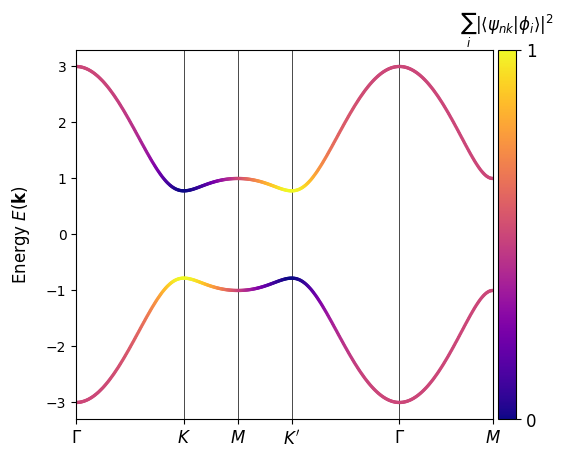

In [3]:
k_nodes = [[0, 0], [2 / 3, 1 / 3], [0.5, 0.5], [1 / 3, 2 / 3], [0, 0], [0.5, 0.5]]
k_labels = (r"$\Gamma $", r"$K$", r"$M$", r"$K^\prime$", r"$\Gamma $", r"$M$")

my_model.plot_bands(
    k_nodes,
    k_node_labels=k_labels,
    nk=501,
    scat_size=2,
    proj_orb_idx=[1],
    cmap="plasma",
)

In [4]:
mesh = Mesh(["k", "k"])
mesh.build_grid(shape=(10, 10), gamma_centered=True, k_endpoints=[True, True])
print(mesh)

Mesh Summary
Type: grid
Dimensionality: 2 k-dim(s) + 0 λ-dim(s)
Number of mesh points: 100
Full shape: (10, 10, 2)
k-axes: [Axis(type=k, name=k_0, size=10), Axis(type=k, name=k_1, size=10)]
λ-axes: []
Is a torus in k-space (all k-axes wind BZ): yes
Loops: (axis 0, comp 0, winds_bz=yes, closed=yes), (axis 1, comp 1, winds_bz=yes, closed=yes)


In [5]:
wfa = WFArray(my_model.lattice, mesh)
wfa.solve_model(my_model)

In [6]:
# Berry phases along k_x for lower band
phi_0 = wfa.berry_phase(axis_idx=0, state_idx=[0], contin=True)
# Berry phases along k_x for upper band
phi_1 = wfa.berry_phase(axis_idx=0, state_idx=[1], contin=True)
# Berry phases along k_x for both bands
phi_both = wfa.berry_phase(axis_idx=0, state_idx=[0, 1], contin=True)

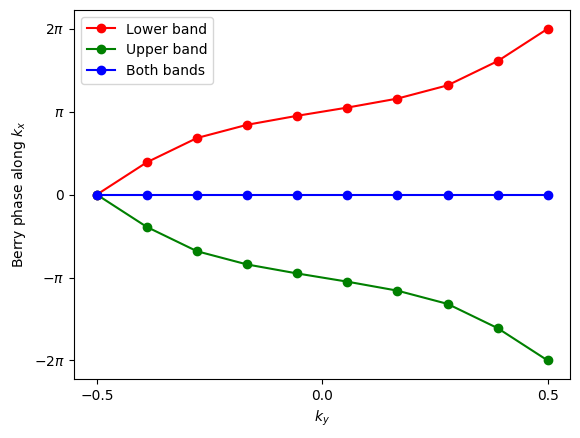

In [7]:
# plot Berry phases
fig, ax = plt.subplots()
ky = mesh.get_axis_range(1, 1)
ax.plot(ky, phi_0, "ro-", label="Lower band")
ax.plot(ky, phi_1, "go-", label="Upper band")
ax.plot(ky, phi_both, "bo-", label="Both bands")

ax.set_xlabel(r"$k_y$")
ax.set_ylabel(r"Berry phase along $k_x$")
ax.xaxis.set_ticks([-0.5, 0, 0.5])
ax.set_ylim(-7.0, 7.0)
ax.yaxis.set_ticks([-2 * np.pi, -np.pi, 0, np.pi, 2 * np.pi])
ax.set_yticklabels((r"$-2\pi$", r"$-\pi$", r"$0$", r"$\pi$", r"$2\pi$"))
ax.legend()

In [8]:
chern0 = wfa.chern_number(state_idx=[0], plane=(0, 1))
chern1 = wfa.chern_number(state_idx=[1], plane=(0, 1))

print(f"Chern number for lower band = {chern0:.11f}")
print(f"Chern number for upper band = {chern1:.11f}")

Chern number for lower band = -1.00000000000
Chern number for upper band = 1.00000000000


In [9]:
bflux = wfa.berry_flux(state_idx=[1], plane=(0, 1))

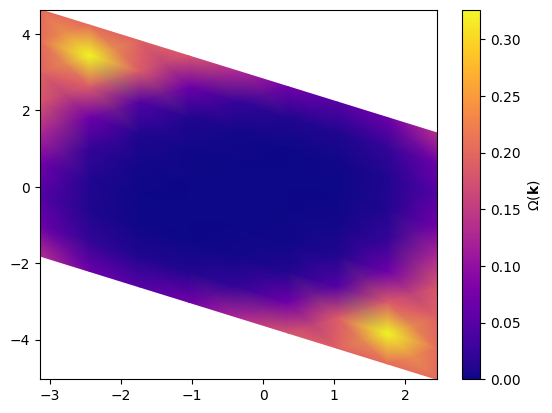

In [10]:
mesh_cart = mesh.points @ my_model.recip_lat_vecs
KX, KY = mesh_cart[..., 0], mesh_cart[..., 1]

im = plt.pcolormesh(KX[:-1, :-1], KY[:-1, :-1], bflux, cmap="plasma", shading="gouraud")
plt.colorbar(label=r"$\Omega(\mathbf{k})$")